# MPC Trajectory Control

**Model Predictive Control for a 2D double-integrator vehicle using Moreau.**

This notebook demonstrates:
- Formulating a linear MPC problem as a QP
- Closed-loop simulation with **warm starting** for fast sequential solves
- **Batched MPC** solving 16 initial conditions in a single call
- Animated visualization of the receding-horizon controller

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
from scipy import sparse
import matplotlib.pyplot as plt
import time

import moreau
from utils.style import set_moreau_style, set_moreau_dark_style, MOREAU_COLORS, moreau_gradient, annotate_speedup
from utils.sparse import sparse_to_csr, build_solver
from utils.animation import fig_to_pil, save_gif, display_gif

set_moreau_style()
np.random.seed(42)

## Double Integrator Dynamics

A point-mass vehicle in 2D with state $\mathbf{x} = [p_x, p_y, v_x, v_y]^\top$ (position + velocity) and control input $\mathbf{u} = [a_x, a_y]^\top$ (acceleration). Discrete-time dynamics with timestep $\Delta t = 0.1$:

$$\mathbf{x}_{k+1} = A \, \mathbf{x}_k + B \, \mathbf{u}_k$$

In [2]:
# System dimensions
nx = 4   # state: [px, py, vx, vy]
nu = 2   # input: [ax, ay]
dt = 0.1

# Discrete-time dynamics matrices
A_dyn = np.array([
    [1, 0, dt, 0],
    [0, 1, 0,  dt],
    [0, 0, 1,  0],
    [0, 0, 0,  1],
])

B_dyn = np.array([
    [0.5 * dt**2, 0],
    [0, 0.5 * dt**2],
    [dt, 0],
    [0,  dt],
])

print(f"State dim: {nx}, Input dim: {nu}, dt = {dt}")
print(f"A_dyn:\n{A_dyn}")
print(f"B_dyn:\n{B_dyn}")

State dim: 4, Input dim: 2, dt = 0.1
A_dyn:
[[1.  0.  0.1 0. ]
 [0.  1.  0.  0.1]
 [0.  0.  1.  0. ]
 [0.  0.  0.  1. ]]
B_dyn:
[[0.005 0.   ]
 [0.    0.005]
 [0.1   0.   ]
 [0.    0.1  ]]


## MPC Problem Formulation

We formulate MPC as a QP over a prediction horizon $N$ with **time-varying reference** $\mathbf{x}^\text{ref}_k$:

$$\min_{\mathbf{x}, \mathbf{u}} \; \sum_{k=0}^{N-1} \left[ (\mathbf{x}_k - \mathbf{x}^\text{ref}_k)^\top Q (\mathbf{x}_k - \mathbf{x}^\text{ref}_k) + \mathbf{u}_k^\top R \, \mathbf{u}_k \right] + (\mathbf{x}_N - \mathbf{x}^\text{ref}_N)^\top Q_f (\mathbf{x}_N - \mathbf{x}^\text{ref}_N)$$

subject to dynamics, initial state, input bounds $|\mathbf{u}_k| \le u_{\max}$, and velocity bounds $|v_k| \le v_{\max}$.

The time-varying reference gives the controller **preview** of the future trajectory, which is critical for accurate tracking of moving targets like our figure-eight.

**Decision variables** are interleaved: $z = [\mathbf{x}_0, \mathbf{u}_0, \mathbf{x}_1, \mathbf{u}_1, \ldots, \mathbf{x}_{N-1}, \mathbf{u}_{N-1}, \mathbf{x}_N]$.

**Moreau's standard form**: $\min \frac{1}{2} z^\top P z + q^\top z$ s.t. $A z + s = b$, $s \in \mathcal{K}$, with cone ordering: zero cones (equalities) first, then nonneg cones (inequalities).

In [3]:
# MPC parameters
N = 50       # prediction horizon
u_max = 2.0  # acceleration bound
v_max = 3.0  # velocity bound

# Cost matrices
Q = np.diag([10.0, 10.0, 1.0, 1.0])   # state cost (penalize position error more)
R = np.diag([0.1, 0.1])                 # input cost
Q_f = 10.0 * Q                          # terminal cost

# Total decision variables: interleaved [x_0, u_0, x_1, u_1, ..., x_{N-1}, u_{N-1}, x_N]
n_vars = (N + 1) * nx + N * nu
print(f"Horizon N = {N}")
print(f"Decision variables: {n_vars}  ({N+1} states x {nx} + {N} inputs x {nu})")

Horizon N = 50
Decision variables: 304  (51 states x 4 + 50 inputs x 2)


In [4]:
# CVXPY equivalent:
#   import cvxpy as cp
#   x = cp.Variable((N + 1, nx))    # states
#   u = cp.Variable((N, nu))        # inputs
#   cost = sum(cp.quad_form(x[k] - x_ref, Q) + cp.quad_form(u[k], R) for k in range(N))
#   cost += cp.quad_form(x[N] - x_ref, Q_f)
#   constraints = [x[0] == x_init]
#   for k in range(N):
#       constraints += [x[k+1] == A_dyn @ x[k] + B_dyn @ u[k]]
#       constraints += [cp.norm_inf(u[k]) <= u_max]
#   for k in range(N + 1):
#       constraints += [cp.norm_inf(x[k, 2:4]) <= v_max]
#   prob = cp.Problem(cp.Minimize(cost), constraints)
#   prob.solve()

def var_idx_x(t):
    """Starting index of state x_t in the decision variable vector."""
    if t < N:
        return t * (nx + nu)
    else:  # t == N (terminal state)
        return N * (nx + nu)


def var_idx_u(t):
    """Starting index of input u_t in the decision variable vector."""
    return t * (nx + nu) + nx


# -------------------------------------------------------
# Cost matrix P (block diagonal)
# -------------------------------------------------------
P_blocks = []
for t in range(N):
    P_blocks.append(2.0 * Q)    # state cost for x_t
    P_blocks.append(2.0 * R)    # input cost for u_t
P_blocks.append(2.0 * Q_f)     # terminal cost for x_N

P = sparse.block_diag(P_blocks, format='csr')
P = P.astype(np.float64)

# -------------------------------------------------------
# Equality constraints (zero cones)
# -------------------------------------------------------
# 1. Dynamics: A_dyn * x_t + B_dyn * u_t - I * x_{t+1} = 0  for t = 0,...,N-1
#    => N * nx rows
# 2. Initial state: I * x_0 = x_init
#    => nx rows

eq_rows = []

# Dynamics constraints
for t in range(N):
    row = sparse.lil_matrix((nx, n_vars))
    row[:, var_idx_x(t):var_idx_x(t)+nx] = A_dyn
    row[:, var_idx_u(t):var_idx_u(t)+nu] = B_dyn
    row[:, var_idx_x(t+1):var_idx_x(t+1)+nx] = -np.eye(nx)
    eq_rows.append(row.tocsr())

A_dynamics = sparse.vstack(eq_rows, format='csr')

# Initial state constraint: x_0 = x_init (b will encode x_init)
A_init = sparse.lil_matrix((nx, n_vars))
A_init[:, 0:nx] = np.eye(nx)
A_init = A_init.tocsr()

A_eq = sparse.vstack([A_dynamics, A_init], format='csr')
n_eq = A_eq.shape[0]  # N*nx + nx = (N+1)*nx

# -------------------------------------------------------
# Inequality constraints (nonneg cones)
# Moreau form: A_ineq z + s = b_ineq, s >= 0  =>  A_ineq z <= b_ineq
# -------------------------------------------------------
ineq_rows = []
b_ineq_parts = []

# Input bounds: -u_max <= u_t <= u_max for t = 0,...,N-1
# Upper: u_t <= u_max  =>  [I_nu] * u_t <= u_max
# Lower: -u_t <= u_max  =>  [-I_nu] * u_t <= u_max
for t in range(N):
    # u_t <= u_max
    row_upper = sparse.lil_matrix((nu, n_vars))
    row_upper[:, var_idx_u(t):var_idx_u(t)+nu] = np.eye(nu)
    ineq_rows.append(row_upper.tocsr())
    b_ineq_parts.append(u_max * np.ones(nu))

    # -u_t <= u_max
    row_lower = sparse.lil_matrix((nu, n_vars))
    row_lower[:, var_idx_u(t):var_idx_u(t)+nu] = -np.eye(nu)
    ineq_rows.append(row_lower.tocsr())
    b_ineq_parts.append(u_max * np.ones(nu))

# Velocity bounds: -v_max <= vx, vy <= v_max for t = 0,...,N
# Velocity components are at indices 2,3 within x_t
for t in range(N + 1):
    x_start = var_idx_x(t)

    # v_t <= v_max
    row_upper = sparse.lil_matrix((2, n_vars))
    row_upper[0, x_start + 2] = 1.0  # vx
    row_upper[1, x_start + 3] = 1.0  # vy
    ineq_rows.append(row_upper.tocsr())
    b_ineq_parts.append(v_max * np.ones(2))

    # -v_t <= v_max
    row_lower = sparse.lil_matrix((2, n_vars))
    row_lower[0, x_start + 2] = -1.0  # -vx
    row_lower[1, x_start + 3] = -1.0  # -vy
    ineq_rows.append(row_lower.tocsr())
    b_ineq_parts.append(v_max * np.ones(2))

A_ineq = sparse.vstack(ineq_rows, format='csr')
b_ineq_fixed = np.concatenate(b_ineq_parts)
n_ineq = A_ineq.shape[0]

# -------------------------------------------------------
# Full constraint matrix: zero cones first, then nonneg
# -------------------------------------------------------
A_full = sparse.vstack([A_eq, A_ineq], format='csr').astype(np.float64)
A_full.sort_indices()
n_constraints = A_full.shape[0]

cones = moreau.Cones(num_zero_cones=n_eq, num_nonneg_cones=n_ineq)

print(f"Equality constraints (zero cones):  {n_eq}")
print(f"Inequality constraints (nonneg):    {n_ineq}")
print(f"Total constraints:                  {n_constraints}")
print(f"P shape: {P.shape}, nnz = {P.nnz}")
print(f"A shape: {A_full.shape}, nnz = {A_full.nnz}")

Equality constraints (zero cones):  204
Inequality constraints (nonneg):    404
Total constraints:                  608
P shape: (304, 304), nnz = 1016
A shape: (608, 304), nnz = 1108


In [5]:
def build_qb(x_init, x_refs):
    """Build the q and b vectors for a given initial state and reference trajectory.

    Parameters
    ----------
    x_init : np.ndarray, shape (4,)
        Current state.
    x_refs : np.ndarray, shape (N+1, 4)
        Time-varying reference states for each horizon step.

    Returns
    -------
    q : np.ndarray, shape (n_vars,)
    b : np.ndarray, shape (n_constraints,)
    """
    # Linear cost q from expanding (x_k - x_ref_k)' Q (x_k - x_ref_k):
    #   = x_k' Q x_k - 2 x_ref_k' Q x_k + const
    # So q contribution for x_k is -2 Q x_ref_k (since P already has 2Q on diagonal)
    q = np.zeros(n_vars)
    for t in range(N):
        q[var_idx_x(t):var_idx_x(t)+nx] = -2.0 * Q @ x_refs[t]
    q[var_idx_x(N):var_idx_x(N)+nx] = -2.0 * Q_f @ x_refs[N]

    # RHS b: equalities first, then inequalities
    b_eq = np.zeros(n_eq)
    # Dynamics rows are zero (A x_t + B u_t - x_{t+1} = 0)
    # Initial state rows: x_0 = x_init
    b_eq[N * nx:N * nx + nx] = x_init

    b = np.concatenate([b_eq, b_ineq_fixed])
    return q, b


def extract_trajectory(z):
    """Extract state and input trajectories from the decision variable."""
    xs = np.zeros((N + 1, nx))
    us = np.zeros((N, nu))
    for t in range(N):
        xs[t] = z[var_idx_x(t):var_idx_x(t)+nx]
        us[t] = z[var_idx_u(t):var_idx_u(t)+nu]
    xs[N] = z[var_idx_x(N):var_idx_x(N)+nx]
    return xs, us


# -------------------------------------------------------
# Test: single MPC step from [3, 3, 0, 0] tracking origin
# -------------------------------------------------------
x_test = np.array([3.0, 3.0, 0.0, 0.0])
x_refs_test = np.zeros((N + 1, nx))  # constant reference at origin
q_test, b_test = build_qb(x_test, x_refs_test)

solver = moreau.Solver(P, q_test, A_full, b_test, cones=cones, settings=moreau.Settings(
    device="cpu",
    ipm_settings=moreau.IPMSettings(direct_solve_method="faer"),
))
sol = solver.solve()

xs_pred, us_pred = extract_trajectory(sol.x)
print(f"Status: {solver.info.status.name}")
print(f"Iterations: {solver.info.iterations}")
print(f"First control: u_0 = [{us_pred[0, 0]:.3f}, {us_pred[0, 1]:.3f}]")
print(f"Predicted final state: x_N = [{xs_pred[-1, 0]:.3f}, {xs_pred[-1, 1]:.3f}, {xs_pred[-1, 2]:.3f}, {xs_pred[-1, 3]:.3f}]")

Status: Solved
Iterations: 9
First control: u_0 = [-2.000, -2.000]
Predicted final state: x_N = [0.000, 0.000, -0.000, -0.000]


## Closed-Loop Simulation with Warm Starting

We run a closed-loop MPC simulation over one full figure-eight period. At each step:
1. Solve the MPC QP for the current state and **time-varying reference** (preview across the horizon)
2. Apply the first control input to the plant
3. Pass the solution as a **warm start** to the next step

The reference trajectory traces a figure-eight pattern. The vehicle starts at the origin **from rest** — since the figure-eight reference immediately demands ~1.8 m/s velocity in each axis, the vehicle must saturate its acceleration bounds ($a_{\max} = 2$ m/s$^2$) for the first ~2 seconds to catch up. This produces a visible **initial transient** in the top-right of the trajectory; once the velocity matches, tracking error drops to near zero.

In [6]:
# Reference trajectory: figure-eight (lemniscate)
n_sim = 120

def figure_eight_ref(t_idx, scale=3.5, period=120):
    """Compute reference state on a figure-eight at simulation step t_idx."""
    theta = 2.0 * np.pi * t_idx / period
    px = scale * np.sin(theta)
    py = scale * np.sin(theta) * np.cos(theta)
    # Reference velocity = derivative of position w.r.t. time
    omega = 2.0 * np.pi / (period * dt)  # rad/s
    vx = scale * np.cos(theta) * omega
    vy = scale * np.cos(2 * theta) * omega
    return np.array([px, py, vx, vy])


# Build a CompiledSolver for warm-started sequential solves
P_ro, P_ci, P_vals = sparse_to_csr(P)
A_ro, A_ci, A_vals = sparse_to_csr(A_full)

settings_seq = moreau.Settings(
    batch_size=1,
    device='cuda',
    ipm_settings=moreau.IPMSettings(direct_solve_method='cudss'),
)
compiled_seq = moreau.CompiledSolver(
    n=n_vars, m=n_constraints,
    P_row_offsets=P_ro, P_col_indices=P_ci,
    A_row_offsets=A_ro, A_col_indices=A_ci,
    cones=cones, settings=settings_seq,
)
compiled_seq.setup(P_vals, A_vals)

def get_iters(info):
    """Extract iteration count from solver info (handles both scalar and list)."""
    iters = info.iterations
    if hasattr(iters, '__getitem__'):
        return int(iters[0])
    return int(iters)

# Storage for results
x_history = np.zeros((n_sim + 1, nx))
u_history = np.zeros((n_sim, nu))
ref_history = np.zeros((n_sim, nx))
pred_horizons = {}  # store a few predicted trajectories for plotting
cold_iters_list = []
warm_iters_list = []

# Initial state: on the figure-eight at t=0 with zero velocity (MPC catches up quickly)
x_current = np.array([0.0, 0.0, 0.0, 0.0])
x_history[0] = x_current

warm_start = None

for step in range(n_sim):
    # Time-varying reference across the prediction horizon
    x_refs_k = np.array([figure_eight_ref(step + t) for t in range(N + 1)])
    ref_history[step] = x_refs_k[0]
    q_k, b_k = build_qb(x_current, x_refs_k)

    # Warm-started solve
    sol_warm = compiled_seq.solve(
        qs=q_k[np.newaxis],
        bs=b_k[np.newaxis],
        warm_start=warm_start,
    )
    warm_iters = get_iters(compiled_seq.info)
    warm_iters_list.append(warm_iters)

    # Cold solve (for comparison) -- only measure iterations, not used for control
    sol_cold = compiled_seq.solve(qs=q_k[np.newaxis], bs=b_k[np.newaxis])
    cold_iters = get_iters(compiled_seq.info)
    cold_iters_list.append(cold_iters)

    # Update warm start from the warm solution
    warm_start = sol_warm.to_warm_start()

    # Extract predicted trajectory and first control
    xs_pred, us_pred = extract_trajectory(sol_warm.x[0])
    u_apply = us_pred[0]

    # Store predicted horizon at selected steps
    if step % 15 == 0 or step == n_sim - 1:
        pred_horizons[step] = xs_pred.copy()

    # Apply control and simulate forward
    x_next = A_dyn @ x_current + B_dyn @ u_apply
    x_current = x_next
    x_history[step + 1] = x_current
    u_history[step] = u_apply

print(f"Simulation complete: {n_sim} steps")
print(f"Average cold iterations: {np.mean(cold_iters_list):.1f}")
print(f"Average warm iterations: {np.mean(warm_iters_list):.1f}")
print(f"Warm start speedup: {np.mean(cold_iters_list) / np.mean(warm_iters_list):.2f}x fewer iterations")

Simulation complete: 120 steps
Average cold iterations: 9.9
Average warm iterations: 6.6
Warm start speedup: 1.51x fewer iterations


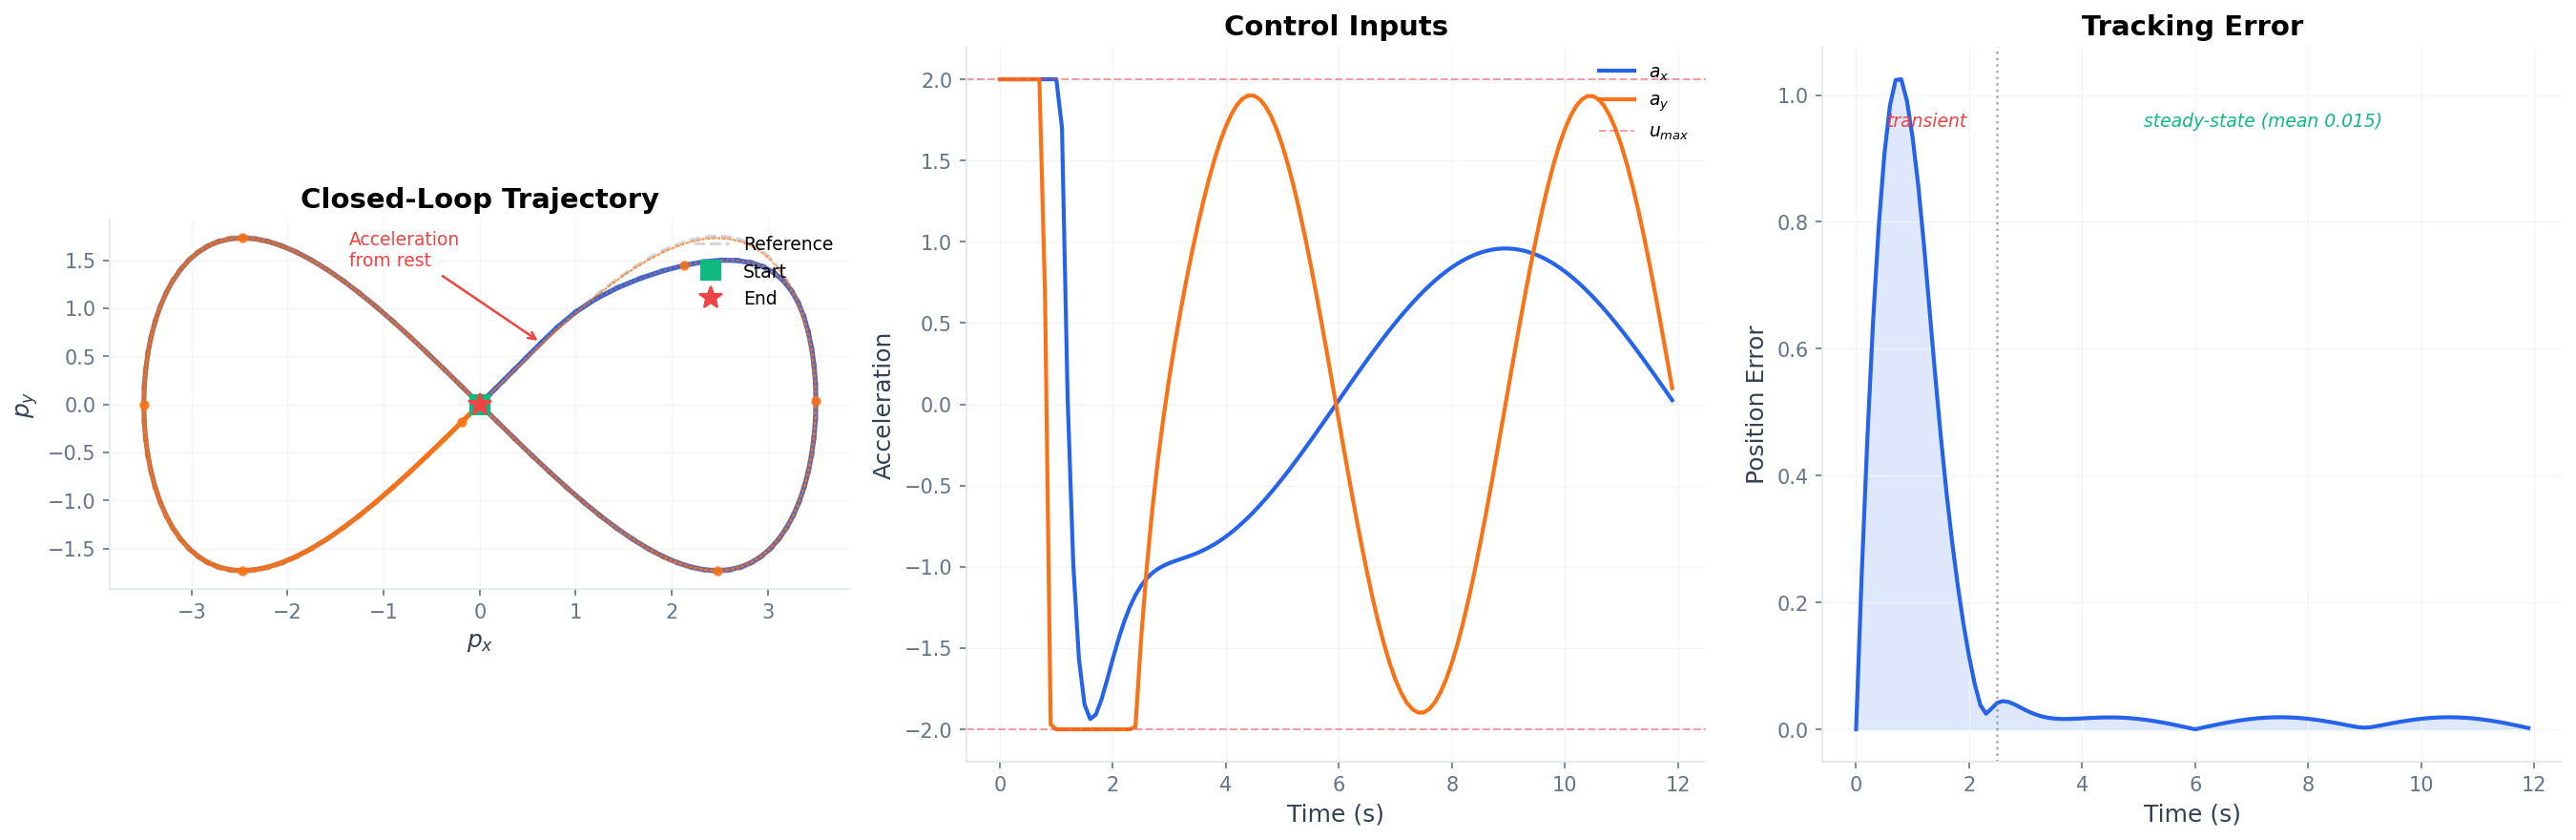

Peak tracking error: 1.025 (during initial transient)
Steady-state error (t > 2.5s): 0.0149


In [7]:
# -------------------------------------------------------
# Plot closed-loop trajectory
# -------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Panel 1: Trajectory in 2D ---
ax = axes[0]

# Reference figure-eight (dense sampling for smooth curve)
ref_dense_t = np.linspace(0, n_sim, 500)
ref_dense = np.array([figure_eight_ref(t) for t in ref_dense_t])
ax.plot(ref_dense[:, 0], ref_dense[:, 1], '--', color=MOREAU_COLORS['neutral_light'],
        linewidth=1.5, label='Reference', zorder=1)

# Actual trajectory
colors = moreau_gradient(n_sim + 1)
for i in range(n_sim):
    ax.plot(x_history[i:i+2, 0], x_history[i:i+2, 1], '-', color=colors[i], linewidth=2.5)

# Predicted horizons
for step, xs_p in pred_horizons.items():
    ax.plot(xs_p[:, 0], xs_p[:, 1], ':', color=MOREAU_COLORS['accent'], linewidth=1.0, alpha=0.6)
    ax.plot(xs_p[0, 0], xs_p[0, 1], 'o', color=MOREAU_COLORS['accent'], markersize=4, alpha=0.8)

# Start and end markers
ax.plot(x_history[0, 0], x_history[0, 1], 's', color=MOREAU_COLORS['success'],
        markersize=10, zorder=10, label='Start')
ax.plot(x_history[-1, 0], x_history[-1, 1], '*', color=MOREAU_COLORS['danger'],
        markersize=12, zorder=10, label='End')

# Annotate initial transient region
peak_err_step = np.argmax(np.sqrt((x_history[:n_sim, 0] - ref_history[:, 0])**2 +
                                   (x_history[:n_sim, 1] - ref_history[:, 1])**2))
ax.annotate('Acceleration\nfrom rest',
            xy=(x_history[peak_err_step, 0], x_history[peak_err_step, 1]),
            xytext=(x_history[peak_err_step, 0] - 2.0, x_history[peak_err_step, 1] + 0.8),
            fontsize=9, color=MOREAU_COLORS['danger'],
            arrowprops=dict(arrowstyle='->', color=MOREAU_COLORS['danger'], lw=1.2),
            zorder=11)

ax.set_xlabel('$p_x$')
ax.set_ylabel('$p_y$')
ax.set_title('Closed-Loop Trajectory')
ax.legend(loc='upper right', fontsize=9)
ax.set_aspect('equal')

# --- Panel 2: Control inputs ---
ax = axes[1]
time_steps = np.arange(n_sim) * dt
ax.plot(time_steps, u_history[:, 0], '-', color=MOREAU_COLORS['primary'], label='$a_x$', linewidth=2)
ax.plot(time_steps, u_history[:, 1], '-', color=MOREAU_COLORS['accent'], label='$a_y$', linewidth=2)
ax.axhline(u_max, color=MOREAU_COLORS['danger'], linestyle='--', linewidth=1, alpha=0.5, label='$u_{max}$')
ax.axhline(-u_max, color=MOREAU_COLORS['danger'], linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Acceleration')
ax.set_title('Control Inputs')
ax.legend(loc='upper right', fontsize=9)

# --- Panel 3: Tracking error ---
ax = axes[2]
pos_error = np.sqrt((x_history[:n_sim, 0] - ref_history[:, 0])**2 +
                     (x_history[:n_sim, 1] - ref_history[:, 1])**2)
ax.plot(time_steps, pos_error, '-', color=MOREAU_COLORS['primary'], linewidth=2)
ax.fill_between(time_steps, 0, pos_error, color=MOREAU_COLORS['primary'], alpha=0.15)

# Mark transient vs steady-state regions
t_settle = 2.5  # approximate settling time in seconds
ax.axvline(t_settle, color=MOREAU_COLORS['neutral'], linestyle=':', linewidth=1.2, alpha=0.6)
y_top = pos_error.max() * 0.95
ax.text(t_settle / 2, y_top, 'transient', ha='center', va='top',
        fontsize=9, color=MOREAU_COLORS['danger'], fontstyle='italic')
ss_error = pos_error[int(t_settle / dt):].mean()
ax.text((t_settle + time_steps[-1]) / 2, y_top, f'steady-state (mean {ss_error:.3f})',
        ha='center', va='top', fontsize=9, color=MOREAU_COLORS['success'], fontstyle='italic')

ax.set_xlabel('Time (s)')
ax.set_ylabel('Position Error')
ax.set_title('Tracking Error')

plt.tight_layout()
plt.savefig('../assets/mpc.png', bbox_inches='tight', facecolor='white')
plt.show()

print(f"Peak tracking error: {pos_error.max():.3f} (during initial transient)")
print(f"Steady-state error (t > {t_settle}s): {ss_error:.4f}")

## Animated MPC Visualization

An animated GIF showing the vehicle following the figure-eight reference, with the MPC predicted horizon displayed at each step.


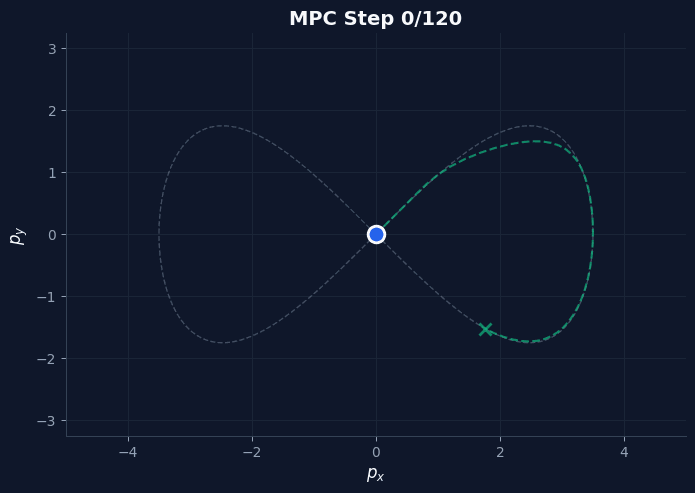

In [8]:
set_moreau_dark_style()

# Re-run simulation to capture all predicted horizons for animation
all_pred_horizons = []
x_current_anim = np.array([0.0, 0.0, 0.0, 0.0])
x_history_anim = np.zeros((n_sim + 1, nx))
x_history_anim[0] = x_current_anim
warm_start_anim = None

for step in range(n_sim):
    x_refs_k = np.array([figure_eight_ref(step + t) for t in range(N + 1)])
    q_k, b_k = build_qb(x_current_anim, x_refs_k)

    sol_k = compiled_seq.solve(
        qs=q_k[np.newaxis],
        bs=b_k[np.newaxis],
        warm_start=warm_start_anim,
    )
    warm_start_anim = sol_k.to_warm_start()

    xs_pred_k, us_pred_k = extract_trajectory(sol_k.x[0])
    all_pred_horizons.append(xs_pred_k.copy())

    u_apply_k = us_pred_k[0]
    x_current_anim = A_dyn @ x_current_anim + B_dyn @ u_apply_k
    x_history_anim[step + 1] = x_current_anim

# Build animation frames
frames = []
trail_length = 20  # number of past positions to show in trail

# Reference path (dense sampling)
ref_dense_anim_t = np.linspace(0, n_sim, 500)
ref_dense_anim = np.array([figure_eight_ref(t) for t in ref_dense_anim_t])

# Compute axis limits from all data
all_x = np.concatenate([x_history_anim[:, 0], ref_dense_anim[:, 0]])
all_y = np.concatenate([x_history_anim[:, 1], ref_dense_anim[:, 1]])
margin = 1.5
xlims = (all_x.min() - margin, all_x.max() + margin)
ylims = (all_y.min() - margin, all_y.max() + margin)

for step in range(n_sim):
    fig, ax = plt.subplots(figsize=(8, 8))

    # Reference path
    ax.plot(ref_dense_anim[:, 0], ref_dense_anim[:, 1], '--',
            color=MOREAU_COLORS['text_secondary'], linewidth=1.0, alpha=0.4)

    # Reference target at current step
    ref_k = figure_eight_ref(step)
    ax.plot(ref_k[0], ref_k[1], 'o', color=MOREAU_COLORS['accent'],
            markersize=10, alpha=0.8, zorder=8)

    # Vehicle trail (fading)
    trail_start = max(0, step - trail_length)
    for i in range(trail_start, step):
        alpha = 0.2 + 0.8 * (i - trail_start) / max(step - trail_start, 1)
        ax.plot(x_history_anim[i:i+2, 0], x_history_anim[i:i+2, 1],
                '-', color=MOREAU_COLORS['primary_light'], linewidth=3, alpha=alpha)

    # Current vehicle position
    ax.plot(x_history_anim[step, 0], x_history_anim[step, 1], 'o',
            color=MOREAU_COLORS['primary'], markersize=12, zorder=10,
            markeredgecolor='white', markeredgewidth=2)

    # Predicted horizon
    pred = all_pred_horizons[step]
    ax.plot(pred[:, 0], pred[:, 1], '--', color=MOREAU_COLORS['success'],
            linewidth=1.5, alpha=0.7, zorder=5)
    ax.plot(pred[-1, 0], pred[-1, 1], 'x', color=MOREAU_COLORS['success'],
            markersize=8, markeredgewidth=2, alpha=0.7, zorder=5)

    ax.set_xlim(xlims)
    ax.set_ylim(ylims)
    ax.set_aspect('equal')
    ax.set_title(f'MPC Step {step}/{n_sim}', fontsize=14, fontweight='bold')
    ax.set_xlabel('$p_x$')
    ax.set_ylabel('$p_y$')

    frames.append(fig_to_pil(fig))
    plt.close(fig)

gif_path = '../assets/mpc_anim.gif'
save_gif(frames, gif_path, fps=15)
display_gif(gif_path)

## Batched MPC: 128 Initial Conditions

Solve the same MPC problem from 128 different starting positions simultaneously using `CompiledSolver` with `batch_size=128`. All problems share the same dynamics, cost matrices, and constraint structure -- only the initial state (encoded in `b`) and reference (encoded in `q`) differ.

In [9]:
set_moreau_style()

n_batch = 128
x_ref_batch = np.zeros((N + 1, nx))  # all track the origin (constant reference)

# Random initial positions in a ring around the origin
rng = np.random.default_rng(123)
angles = np.linspace(0, 2 * np.pi, n_batch, endpoint=False)
radii = 3.0 + rng.uniform(-0.5, 0.5, n_batch)
x_inits = np.zeros((n_batch, nx))
x_inits[:, 0] = radii * np.cos(angles)  # px
x_inits[:, 1] = radii * np.sin(angles)  # py
# Initial velocities are zero

# Build batched q and b
qs_batch = np.zeros((n_batch, n_vars))
bs_batch = np.zeros((n_batch, n_constraints))

for i in range(n_batch):
    q_i, b_i = build_qb(x_inits[i], x_ref_batch)
    qs_batch[i] = q_i
    bs_batch[i] = b_i

# Build CompiledSolver with batch_size=128
settings_batch = moreau.Settings(
    batch_size=n_batch,
    device='cuda',
    ipm_settings=moreau.IPMSettings(direct_solve_method='cudss'),
)
compiled_batch = moreau.CompiledSolver(
    n=n_vars, m=n_constraints,
    P_row_offsets=P_ro, P_col_indices=P_ci,
    A_row_offsets=A_ro, A_col_indices=A_ci,
    cones=cones, settings=settings_batch,
)
compiled_batch.setup(P_vals, A_vals)

sol_batch = compiled_batch.solve(qs=qs_batch, bs=bs_batch)

print(f"Solved {n_batch} MPC problems in a single batched call")
print(f"All solved: {all(s.name == 'Solved' for s in compiled_batch.info.status)}")

Solved 128 MPC problems in a single batched call
All solved: True


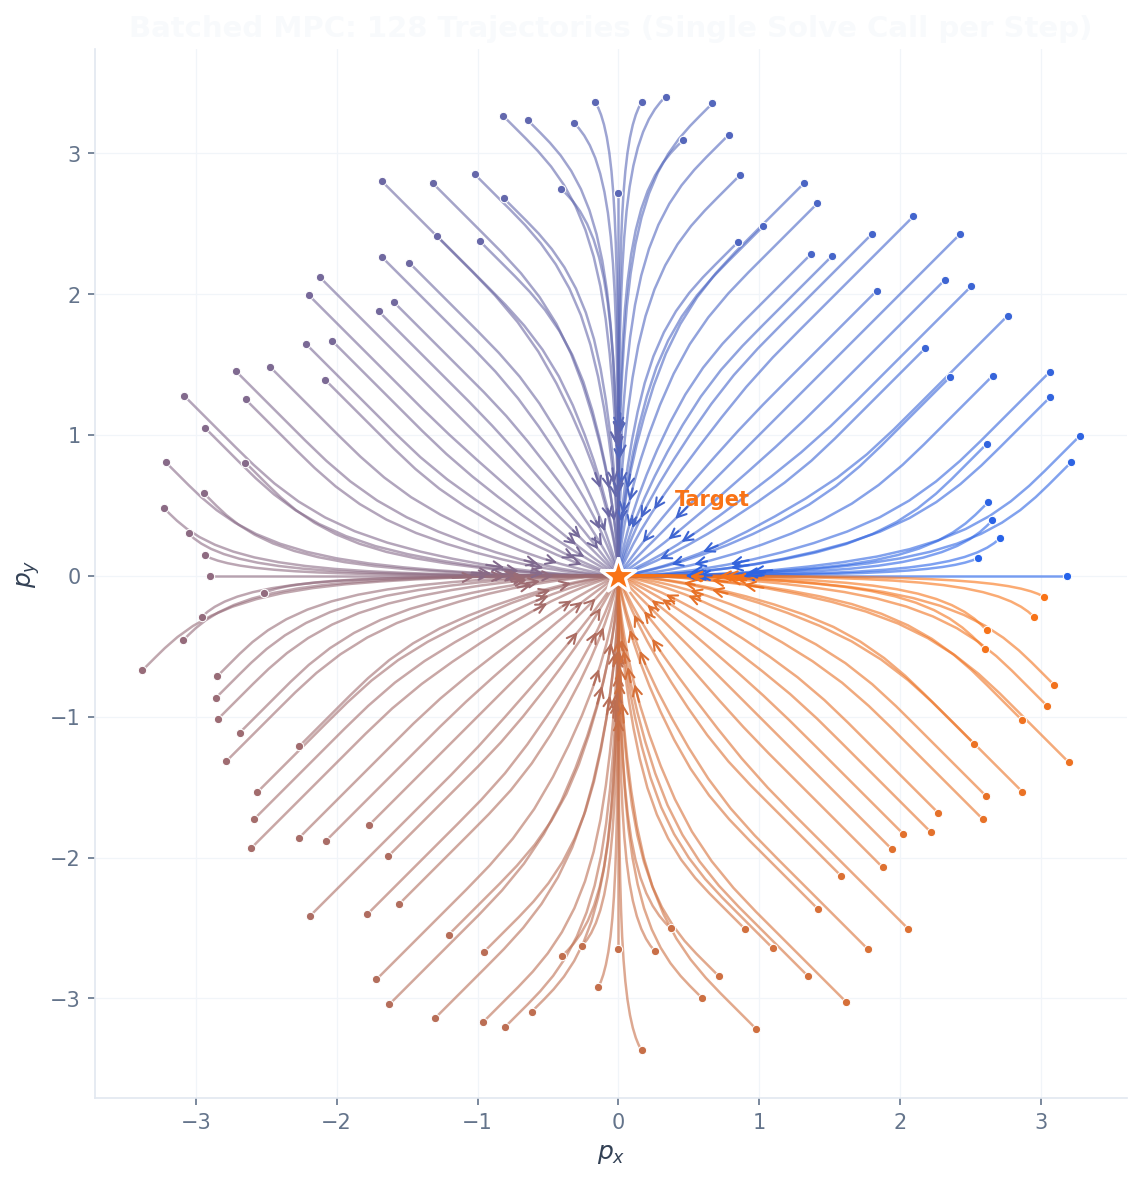

In [10]:
# Simulate closed-loop for all 128 initial conditions (30 steps each for flow-field effect)
n_sim_batch = 30
all_trajectories = np.zeros((n_batch, n_sim_batch + 1, nx))
all_trajectories[:, 0, :] = x_inits

# Solve sequentially for each time step, batched across initial conditions
x_currents = x_inits.copy()
ws_batch = None

for step in range(n_sim_batch):
    qs_step = np.zeros((n_batch, n_vars))
    bs_step = np.zeros((n_batch, n_constraints))
    for i in range(n_batch):
        q_i, b_i = build_qb(x_currents[i], x_ref_batch)
        qs_step[i] = q_i
        bs_step[i] = b_i

    sol_step = compiled_batch.solve(qs=qs_step, bs=bs_step, warm_start=ws_batch)
    ws_batch = sol_step.to_warm_start()

    for i in range(n_batch):
        _, us_i = extract_trajectory(sol_step.x[i])
        x_currents[i] = A_dyn @ x_currents[i] + B_dyn @ us_i[0]
        all_trajectories[i, step + 1] = x_currents[i]

# -------------------------------------------------------
# Plot all 128 trajectories overlaid (flow-field effect)
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 8))

colors_batch = moreau_gradient(n_batch)
for i in range(n_batch):
    traj = all_trajectories[i]
    ax.plot(traj[:, 0], traj[:, 1], '-', color=colors_batch[i], linewidth=1.2, alpha=0.6)
    ax.plot(traj[0, 0], traj[0, 1], 'o', color=colors_batch[i], markersize=4,
            markeredgecolor='white', markeredgewidth=0.5, zorder=5)
    # Arrow at midpoint showing direction
    mid = n_sim_batch // 2
    dx = traj[mid + 1, 0] - traj[mid, 0]
    dy = traj[mid + 1, 1] - traj[mid, 1]
    ax.annotate('', xy=(traj[mid, 0] + dx, traj[mid, 1] + dy),
                xytext=(traj[mid, 0], traj[mid, 1]),
                arrowprops=dict(arrowstyle='->', color=colors_batch[i], lw=1.0))

# Origin target
ax.plot(0, 0, '*', color=MOREAU_COLORS['accent'], markersize=18,
        markeredgecolor='white', markeredgewidth=1.5, zorder=10)
ax.annotate('Target', xy=(0, 0), xytext=(0.4, 0.5), fontsize=10,
            color=MOREAU_COLORS['accent'], fontweight='bold')

ax.set_xlabel('$p_x$')
ax.set_ylabel('$p_y$')
ax.set_title(f'Batched MPC: {n_batch} Trajectories (Single Solve Call per Step)')
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('../assets/mpc_batch.png', bbox_inches='tight', facecolor='white')
plt.show()

## Warm Starting Comparison

Comparing the number of interior-point iterations needed with and without warm starting across the closed-loop simulation.

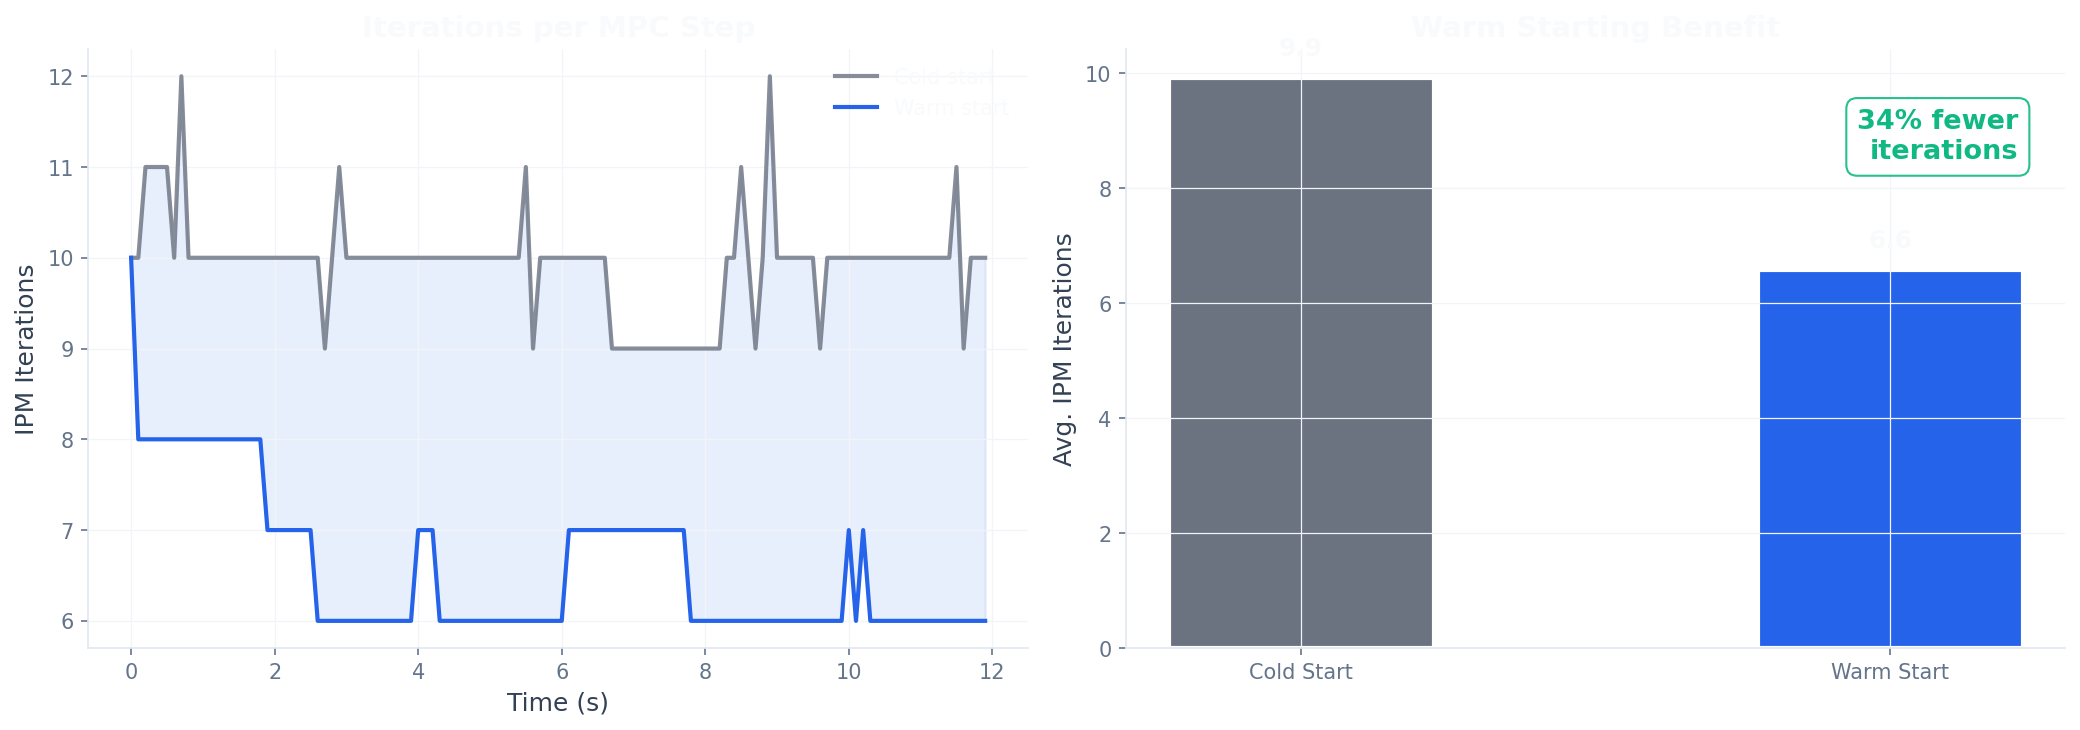

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Panel 1: Iterations over time ---
ax = axes[0]
time_steps_sim = np.arange(n_sim) * dt
ax.plot(time_steps_sim, cold_iters_list, '-', color=MOREAU_COLORS['neutral'],
        linewidth=2, label='Cold start', alpha=0.8)
ax.plot(time_steps_sim, warm_iters_list, '-', color=MOREAU_COLORS['primary'],
        linewidth=2, label='Warm start')
ax.fill_between(time_steps_sim, warm_iters_list, cold_iters_list,
                color=MOREAU_COLORS['primary'], alpha=0.1)
ax.set_xlabel('Time (s)')
ax.set_ylabel('IPM Iterations')
ax.set_title('Iterations per MPC Step')
ax.legend(fontsize=10)

# --- Panel 2: Summary bar chart ---
ax = axes[1]
mean_cold = np.mean(cold_iters_list)
mean_warm = np.mean(warm_iters_list)
bars = ax.bar(['Cold Start', 'Warm Start'],
              [mean_cold, mean_warm],
              color=[MOREAU_COLORS['neutral'], MOREAU_COLORS['primary']],
              width=0.45, edgecolor='white', linewidth=2)

for bar, val in zip(bars, [mean_cold, mean_warm]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{val:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=12)

ax.set_ylabel('Avg. IPM Iterations')
ax.set_title('Warm Starting Benefit')

if mean_warm > 0:
    reduction = (mean_cold - mean_warm) / mean_cold * 100
    ax.annotate(
        f'{reduction:.0f}% fewer\niterations',
        xy=(0.95, 0.90), xycoords='axes fraction',
        ha='right', va='top', fontsize=13, fontweight='bold',
        color=MOREAU_COLORS['success'],
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor=MOREAU_COLORS['success'], alpha=0.9),
    )

plt.tight_layout()
plt.savefig('../assets/mpc_warmstart.png', bbox_inches='tight', facecolor='white')
plt.show()

---

**Key takeaways:**
- MPC is naturally suited to Moreau: every timestep solves a QP with the **same structure** but different parameters
- **Warm starting** from the previous solution reduces iteration count in sequential MPC
- **Batched solving** with `CompiledSolver` handles multiple initial conditions in a single call, amortizing solver overhead
- The interleaved variable ordering $[\mathbf{x}_0, \mathbf{u}_0, \ldots, \mathbf{x}_N]$ keeps the constraint matrix sparse and banded